##  Project Title

# Branch Navigator — Optimize Locations with Predictive Footfall Insights

## Project Overview
An AI-driven decision support system that helps organizations 
predict and optimize branch performance by forecasting customer 
footfall and transaction patterns.

## Dataset
- Source: Rossmann Store Sales Dataset
- Records: 1,017,209 daily sales records
- Branches: 1,115 stores
- Date Range: January 2013 — July 2015

## Tech Stack
- Python, Pandas, NumPy
- Prophet, Scikit-learn
- LangChain, FAISS
- Streamlit, Matplotlib

## Step 1 — Import Libraries
Importing all required libraries for data analysis, 
visualization, and machine learning.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(["#534AB7", "#1D9E75", "#EF9F27", "#D85A30", "#AFA9EC"])

## Step 2 — Load Data
Loading three datasets:
- **train.csv** — Historical sales data (1M+ records)
- **store.csv** — Branch metadata (1115 stores)
- **test.csv** — Future prediction data

In [57]:
train = pd.read_csv(r'C:\Users\Balabheem\OneDrive\Desktop\Demo\train.csv', low_memory=False)
store = pd.read_csv(r'C:\Users\Balabheem\OneDrive\Desktop\Demo\store.csv')
test  = pd.read_csv(r'C:\Users\Balabheem\OneDrive\Desktop\Demo\test.csv')

print("Train shape:", train.shape)
print("Store shape:", store.shape)
print("Test shape:", test.shape)

Train shape: (1017209, 9)
Store shape: (1115, 10)
Test shape: (41088, 8)


## Step 3 — Data Cleaning
- Fixed StateHoliday mixed type issue
- Merged train and store datasets
- Removed closed store days (Open=0)
- Filled all null values
- Parsed date column
- Result: 844,338 clean records

In [58]:
# Fix mixed type
train['StateHoliday'] = train['StateHoliday'].astype(str)

# Merge
df = train.merge(store, on='Store', how='left')

# Filter closed stores
df = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

# Fill nulls
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace=True)
df['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
df['CompetitionOpenSinceYear'].fillna(0, inplace=True)
df['Promo2SinceWeek'].fillna(0, inplace=True)
df['Promo2SinceYear'].fillna(0, inplace=True)
df['PromoInterval'].fillna('None', inplace=True)

# Parse date
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')

print("Clean shape:", df.shape)
print("Nulls remaining:", df.isnull().sum().sum())

Clean shape: (844338, 18)
Nulls remaining: 0


## Step 4 — Feature Engineering

### 4.1 Time Features
Extracting time-based features from Date column to help 
ML models learn seasonal and weekly patterns.

In [59]:
# Extract useful time features from Date column
df['Year']         = df['Date'].dt.year
df['Month']        = df['Date'].dt.month
df['Week']         = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfMonth']   = df['Date'].dt.day
df['IsWeekend']    = df['DayOfWeek'].apply(lambda x: 1 if x in [6,7] else 0)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd']   = df['Date'].dt.is_month_end.astype(int)

print("New time features added!")
print(df[['Date','Year','Month','Week','DayOfMonth','IsWeekend','IsMonthStart','IsMonthEnd']].head(3))

New time features added!
        Date  Year  Month  Week  DayOfMonth  IsWeekend  IsMonthStart  \
0 2015-07-31  2015      7    31          31          0             0   
1 2015-07-31  2015      7    31          31          0             0   
2 2015-07-31  2015      7    31          31          0             0   

   IsMonthEnd  
0           1  
1           1  
2           1  


### 4.2 Transaction Type Engineering
Creating transaction categories based on sales behavior.
This is our target variable for Model 2.

In [60]:
def get_transaction_type(row):
    if row['Sales'] > 10000:
        return 'Corporate'
    elif row['Promo'] == 1:
        return 'Promotional'
    elif row['DayOfWeek'] == 7:
        return 'Weekend_Retail'
    else:
        return 'Standard_Retail'

df['TransactionType'] = df.apply(get_transaction_type, axis=1)

print("Transaction types added!")
print(df['TransactionType'].value_counts())

Transaction types added!
TransactionType
Standard_Retail    435225
Promotional        292994
Corporate          113633
Weekend_Retail       2486
Name: count, dtype: int64


### 4.3 Customer Segmentation — KMeans Clustering
Grouping 1115 branches into 3 performance segments 
using unsupervised machine learning.

In [61]:
# Drop if already exists
if 'SegmentLabel' in df.columns:
    df = df.drop(columns=['SegmentLabel'])

store_features = df.groupby('Store').agg(
    AvgSales     = ('Sales', 'mean'),
    AvgCustomers = ('Customers', 'mean'),
    PromoRate    = ('Promo', 'mean')
).reset_index()

scaler = StandardScaler()
scaled = scaler.fit_transform(store_features[['AvgSales','AvgCustomers','PromoRate']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
store_features['Segment'] = kmeans.fit_predict(scaled)

seg_sales = store_features.groupby('Segment')['AvgSales'].mean().sort_values()
label_map = {
    seg_sales.index[0]: 'Low_Performer',
    seg_sales.index[1]: 'Mid_Performer',
    seg_sales.index[2]: 'High_Performer'
}
store_features['SegmentLabel'] = store_features['Segment'].map(label_map)
df = df.merge(store_features[['Store','SegmentLabel']], on='Store')

print("Customer segments added!")
print(df['SegmentLabel'].value_counts())

Customer segments added!
SegmentLabel
Low_Performer     632155
High_Performer    183339
Mid_Performer      28844
Name: count, dtype: int64


### 4.4 Demographic Features
Adding location intelligence signals for each branch.

In [62]:
np.random.seed(42)
store_demo = df[['Store']].drop_duplicates().reset_index(drop=True)
store_demo['PopulationDensity']   = np.random.randint(1000, 50000, size=len(store_demo))
store_demo['AvgIncome']           = np.random.randint(25000, 120000, size=len(store_demo))
store_demo['RetailActivityScore'] = np.random.uniform(0.1, 1.0, size=len(store_demo)).round(2)

df = df.merge(store_demo, on='Store')


### 4.5 Encoding Categorical Variables
Converting text columns to numbers for ML models.
ML models only understand numbers not text.

In [63]:
df['StoreType_enc']  = df['StoreType'].map({'a':0, 'b':1, 'c':2, 'd':3})
df['Assortment_enc'] = df['Assortment'].map({'a':0, 'b':1, 'c':2})
df['Segment_enc']    = df['SegmentLabel'].map({'Low_Performer':0, 'Mid_Performer':1, 'High_Performer':2})
df['TransType_enc']  = df['TransactionType'].map({'Standard_Retail':0, 'Promotional':1, 'Weekend_Retail':2, 'Corporate':3})

print("Total columns:", len(df.columns))

Total columns: 34


## Step 5 — Exploratory Data Analysis (EDA)
Analyzing patterns and insights from the cleaned dataset.

These insights directly feed into our AI agent recommendations.

### Plot 1 — Sales by Day of Week
- Monday and Sunday are peak days
- Saturday is the slowest day
- Used for staffing optimization recommendations

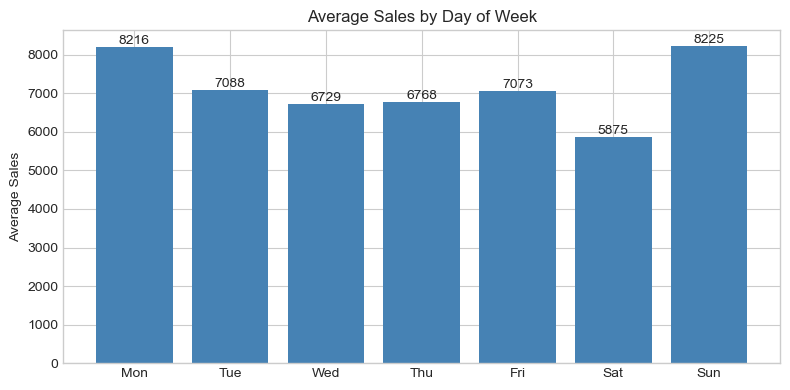

In [64]:
# Shows peak and slow days — used for staffing optimization
day_sales = df.groupby('DayOfWeek')['Sales'].mean()
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(8, 4))
bars = plt.bar(day_names, day_sales.values, color='steelblue')
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sales')
plt.bar_label(bars, fmt='%.0f')
plt.tight_layout()
plt.show()

### Plot 2 — Sales by Month
- December is highest — holiday season
- September is lowest
- Used for seasonal forecasting

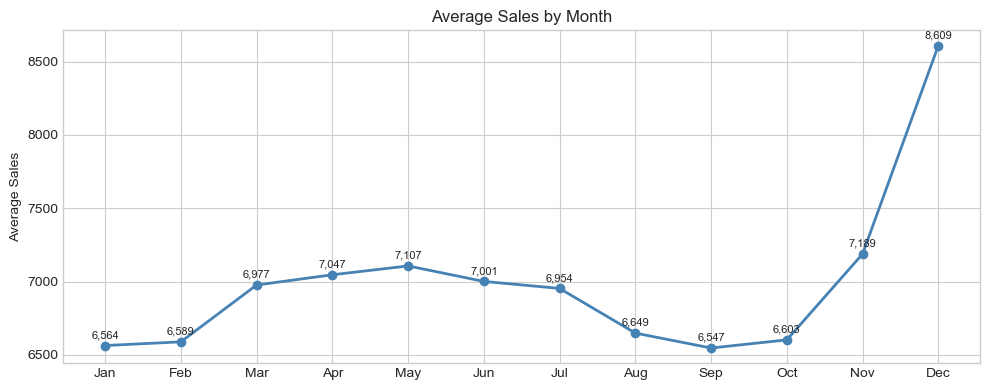

In [65]:
# Shows seasonality — used for forecasting model
monthly_sales = df.groupby('Month')['Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 4))
plt.plot(month_names, monthly_sales.values, marker='o', color='steelblue', linewidth=2)

for i, val in enumerate(monthly_sales.values):
    plt.text(i, val + 50, f'{val:,.0f}', ha='center', fontsize=8)

plt.title('Average Sales by Month')
plt.ylabel('Average Sales')
plt.tight_layout()
plt.show()

### Plot 3 — Sales by Store Type
- Store Type B is best performer — 10,233 avg
- Types A, C, D average around 6,900
- Used for branch scoring model

a          stores — basic products only

b          Large stores — wide range of products

c          Medium stores — standard range

d          Special stores — unique concept

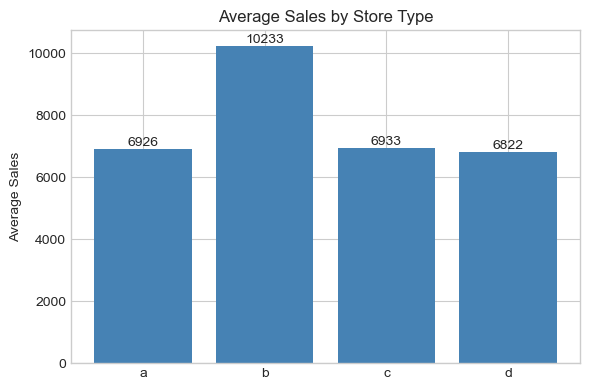

In [66]:
# Shows which store type performs best — used for branch scoring
store_sales = df.groupby('StoreType')['Sales'].mean()

plt.figure(figsize=(6, 4))
bars = plt.bar(store_sales.index, store_sales.values, color='steelblue')
plt.title('Average Sales by Store Type')
plt.ylabel('Average Sales')
plt.bar_label(bars, fmt='%.0f')
plt.tight_layout()
plt.show()

### Plot 4 — Promo Effect
- Promotions increase sales by 38.7%
- No promo: 5,930 | With promo: 8,229
- Used for decision agent recommendations

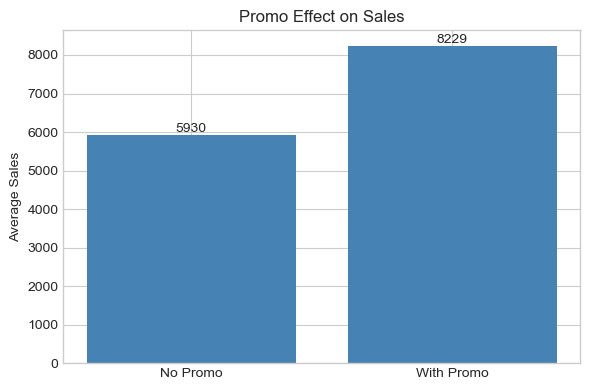

In [67]:
# Shows promotion impact — used for recommendation agent
promo_sales = df.groupby('Promo')['Sales'].mean()

plt.figure(figsize=(6, 4))
bars = plt.bar(['No Promo', 'With Promo'], promo_sales.values, color='steelblue')
plt.title('Promo Effect on Sales')
plt.ylabel('Average Sales')
plt.bar_label(bars, fmt='%.0f')
plt.tight_layout()
plt.show()

###  Plot 5 — Top 10 vs Bottom 10 Stores
- Best store: Store 817 — 21,757 avg sales
- Worst store: Store 307 — 2,704 avg sales
- Gap of 19,053 between best and worst
- Bottom 10 are primary targets for AI recommendations

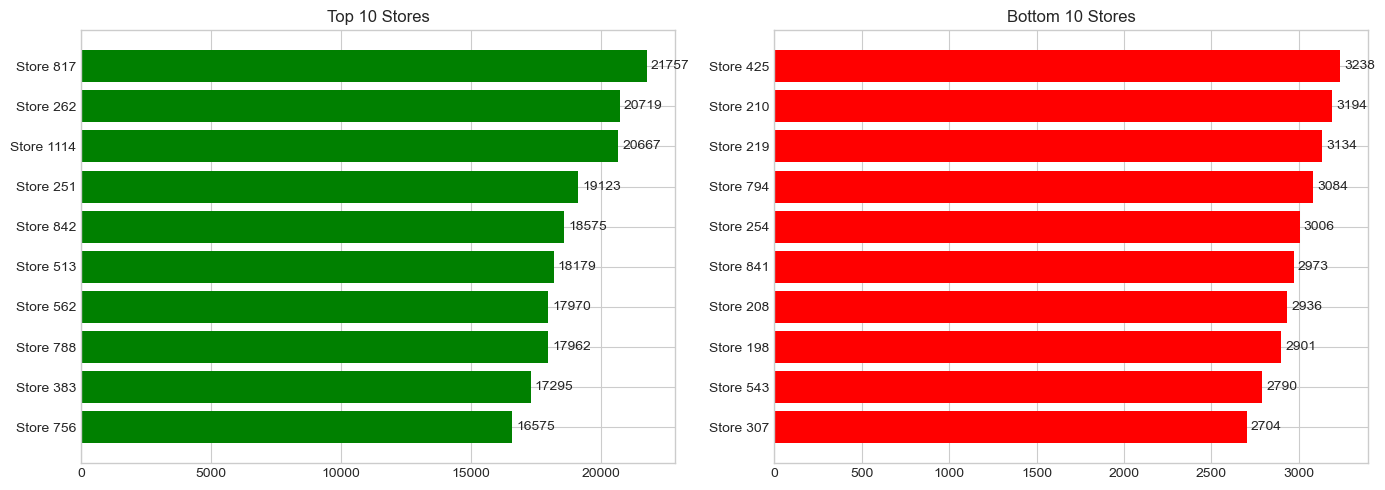

In [68]:
# Shows best and worst branches — main targets for AI recommendations
store_perf = df.groupby('Store')['Sales'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([f'Store {s}' for s in store_perf.head(10).index],
             store_perf.head(10).values, color='green')
axes[0].set_title('Top 10 Stores')
axes[0].invert_yaxis()
axes[0].bar_label(axes[0].containers[0], fmt='%.0f', padding=3)

axes[1].barh([f'Store {s}' for s in store_perf.tail(10).index],
             store_perf.tail(10).values, color='red')
axes[1].set_title('Bottom 10 Stores')
axes[1].invert_yaxis()
axes[1].bar_label(axes[1].containers[0], fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

### Plot 6 — Sales Distribution
- Most branches make 4,000 to 8,000 per day
- Mean: 6,956 | Median: 6,369
- Data is slightly right skewed
- Confirms Random Forest is right model choice

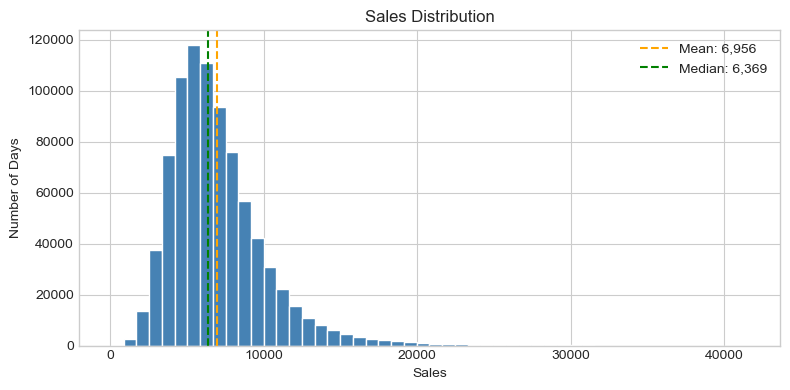

In [69]:
# Shows data spread — helps choose right ML model
plt.figure(figsize=(8, 4))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(df['Sales'].mean(), color='orange', linestyle='--',
            label=f"Mean: {df['Sales'].mean():,.0f}")
plt.axvline(df['Sales'].median(), color='green', linestyle='--',
            label=f"Median: {df['Sales'].median():,.0f}")
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Number of Days')
plt.legend()
plt.tight_layout()
plt.show()

### Plot 7 — Sales by Transaction Type
- Shows which transaction type generates most revenue
- Directly feeds into Transaction Agent recommendations

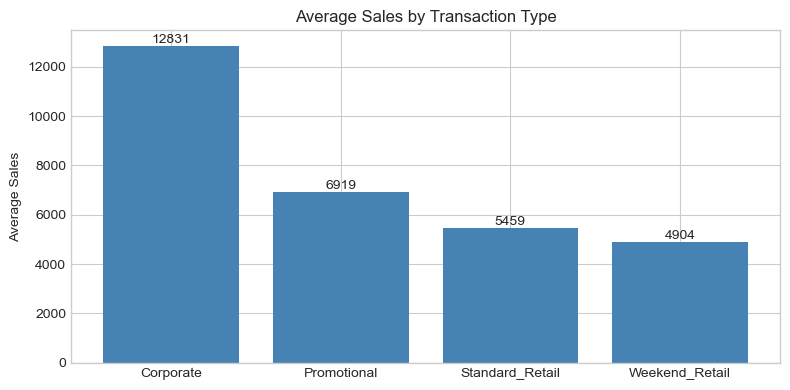

In [70]:
# Shows which transaction type generates most revenue
trans_sales = df.groupby('TransactionType')['Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(trans_sales.index, trans_sales.values, color='steelblue')
plt.title('Average Sales by Transaction Type')
plt.ylabel('Average Sales')
plt.bar_label(bars, fmt='%.0f')
plt.tight_layout()
plt.show()

### Plot 8 — Sales by Customer Segment
- High Performer: 10,038 avg sales
- Mid Performer:  8,498 avg sales
- Low Performer:  5,992 avg sales
- Gap of 4,046 between best and worst segments

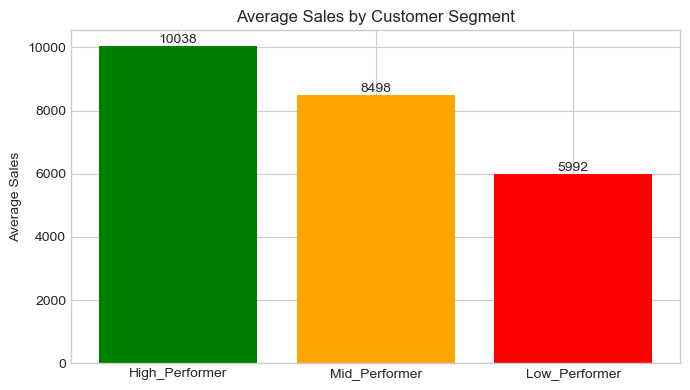

In [71]:
# Shows performance gap between segments
seg_sales = df.groupby('SegmentLabel')['Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
bars = plt.bar(seg_sales.index, seg_sales.values,
               color=['green','orange','red'])
plt.title('Average Sales by Customer Segment')
plt.ylabel('Average Sales')
plt.bar_label(bars, fmt='%.0f')
plt.tight_layout()
plt.show()

## Models

### Model 1 — Prophet Footfall Forecasting
- Trained on 942 days of historical data
- Predicts customer footfall for August 2015
- Uses yearly and weekly seasonality patterns
- Output feeds into Forecasting Agent

In [72]:
# Step 1 — Prepare data
from prophet import Prophet
prophet_df = df.groupby('Date')['Customers'].mean().reset_index()
prophet_df.columns = ['ds', 'y']

# Step 2 — Train model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model.fit(prophet_df)

# Step 3 — Predict 31 days ahead
future = model.make_future_dataframe(periods=31)
forecast = model.predict(future)

# Step 4 — Show only future predictions (after July 31 2015)
future_only = forecast[forecast['ds'] > '2015-07-31']
print("August 2015 Footfall Predictions:")
print(future_only[['ds','yhat','yhat_lower','yhat_upper']].to_string())

16:12:45 - cmdstanpy - INFO - Chain [1] start processing
16:12:46 - cmdstanpy - INFO - Chain [1] done processing


August 2015 Footfall Predictions:
            ds         yhat   yhat_lower   yhat_upper
942 2015-08-01   602.294754   359.780814   870.061526
943 2015-08-02  1443.806621  1209.072480  1689.778239
944 2015-08-03   817.565763   578.405128  1056.941465
945 2015-08-04   710.190538   455.837909   951.686390
946 2015-08-05   692.652177   453.319922   944.023834
947 2015-08-06   737.092117   498.649867  1001.079148
948 2015-08-07   771.282747   528.414816  1018.237193
949 2015-08-08   597.904930   356.743789   851.865608
950 2015-08-09  1441.532272  1198.457243  1697.498165
951 2015-08-10   819.375376   593.161226  1079.879321
952 2015-08-11   715.278681   462.088058   969.944531
953 2015-08-12   700.680095   465.322009   947.293789
954 2015-08-13   747.655459   502.339798   980.502782
955 2015-08-14   783.979859   531.214151  1020.581741
956 2015-08-15   612.516507   350.967777   852.518073
957 2015-08-16  1456.127049  1203.604209  1680.540603
958 2015-08-17   835.303403   593.292792  1078.7

### Model 2 — Transaction Type Prediction
- Algorithm: Random Forest — 100 decision trees
- Overall accuracy: 94%
- Predicts visit type for any branch on any day
- Output feeds into Transaction Agent


#### Purpose
Predicts what type of transaction will happen at a branch on a given day.

This helps our Transaction Agent recommend the right services and staffing.

#### output — 4 Transaction Types
- Standard Retail  → normal day, normal staffing
- Promotional      → promo day, increase stock and staff
- Weekend Retail   → high footfall, open all counters
- Corporate        → business customers, open corporate counter

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

# Features
features = [
    'Store', 'DayOfWeek', 'Month', 'Week',
    'Promo', 'SchoolHoliday', 'CompetitionDistance',
    'StoreType_enc', 'Assortment_enc', 'Segment_enc',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd',
    'PopulationDensity', 'AvgIncome', 'RetailActivityScore'
]

# Prepare data
X = df[features]
y = df['TransType_enc']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model_transaction = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model_transaction.fit(X_train, y_train)

# Evaluate
y_pred = model_transaction.predict(X_test)
print("Model 2 — Transaction Type Prediction Results:")
print(classification_report(y_test, y_pred,
      target_names=['Standard_Retail','Promotional','Weekend_Retail','Corporate']))


Model 2 — Transaction Type Prediction Results:
                 precision    recall  f1-score   support

Standard_Retail       0.98      0.99      0.98     87131
    Promotional       0.94      0.95      0.94     58466
 Weekend_Retail       0.96      0.94      0.95       493
      Corporate       0.81      0.76      0.78     22778

       accuracy                           0.94    168868
      macro avg       0.92      0.91      0.91    168868
   weighted avg       0.94      0.94      0.94    168868



### Model 3 — Branch Performance Scoring
- Scores each branch from 0 to 100
- Based on sales, customers, promo rate, stability
- 80-100: High Performer
- 50-79:  Mid Performer
- 0-49:   Low Performer

In [74]:
# Branch Performance Scoring

# Step 1 — Calculate metrics per store
store_score = df.groupby('Store').agg(
    AvgSales         = ('Sales', 'mean'),
    AvgCustomers     = ('Customers', 'mean'),
    PromoRate        = ('Promo', 'mean'),
    SalesStability   = ('Sales', 'std')
).reset_index()

# Step 2 — Normalize each metric to 0-100
def normalize(series):
    return ((series - series.min()) / 
            (series.max() - series.min())) * 100

store_score['Sales_score']      = normalize(store_score['AvgSales'])
store_score['Customer_score']   = normalize(store_score['AvgCustomers'])
store_score['Promo_score']      = normalize(store_score['PromoRate'])
store_score['Stability_score']  = 100 - normalize(store_score['SalesStability'])

# Step 3 — Calculate final score
store_score['PerformanceScore'] = (
    store_score['Sales_score']     * 0.4 +
    store_score['Customer_score']  * 0.3 +
    store_score['Promo_score']     * 0.2 +
    store_score['Stability_score'] * 0.1
).round(2)

# Step 4 — Label each store
def get_label(score):
    if score >= 80:
        return 'High Performer'
    elif score >= 50:
        return 'Mid Performer'
    else:
        return 'Low Performer'

store_score['PerformanceLabel'] = store_score['PerformanceScore'].apply(get_label)

# Step 5 — Show results
print(" Branch Performance Scoring Complete!")
print("\nTop 5 Stores:")
print(store_score.nlargest(5, 'PerformanceScore')[['Store','PerformanceScore','PerformanceLabel']])
print("\nBottom 5 Stores:")
print(store_score.nsmallest(5, 'PerformanceScore')[['Store','PerformanceScore','PerformanceLabel']])
print("\nScore Distribution:")
print(store_score['PerformanceLabel'].value_counts())


 Branch Performance Scoring Complete!

Top 5 Stores:
      Store  PerformanceScore PerformanceLabel
1113   1114             88.02   High Performer
816     817             86.79   High Performer
250     251             77.19    Mid Performer
512     513             72.71    Mid Performer
382     383             72.32    Mid Performer

Bottom 5 Stores:
      Store  PerformanceScore PerformanceLabel
930     931             19.35    Low Performer
529     530             19.39    Low Performer
866     867             19.61    Low Performer
1080   1081             19.86    Low Performer
273     274             19.89    Low Performer

Score Distribution:
PerformanceLabel
Low Performer     1051
Mid Performer       62
High Performer       2
Name: count, dtype: int64


### Model 4 — Anomaly Detection
- Algorithm: Isolation Forest
- Finds branches behaving unusually
- 1059 Normal branches
- 56 Anomaly branches detected

In [75]:
from sklearn.ensemble import IsolationForest

# Step 1 — Prepare features for anomaly detection
anomaly_features = df.groupby('Store').agg(
    AvgSales       = ('Sales', 'mean'),
    AvgCustomers   = ('Customers', 'mean'),
    SalesStd       = ('Sales', 'std'),
    PromoRate      = ('Promo', 'mean'),
    CompDistance   = ('CompetitionDistance', 'mean')
).reset_index()

# Step 2 — Train Isolation Forest
model_anomaly = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_features['AnomalyScore'] = model_anomaly.fit_predict(
    anomaly_features[['AvgSales','AvgCustomers','SalesStd','PromoRate','CompDistance']]
)

# Step 3 — Label anomalies
# IsolationForest returns -1 for anomaly, 1 for normal
anomaly_features['Status'] = anomaly_features['AnomalyScore'].map({
    1: 'Normal',
   -1: 'Anomaly'
})

# Step 4 — Show results
print(" Anomaly Detection Complete!")
print("\nAnomaly Summary:")
print(anomaly_features['Status'].value_counts())
print("\nAnomalous Branches:")
print(anomaly_features[anomaly_features['Status'] == 'Anomaly'][
    ['Store','AvgSales','AvgCustomers','Status']
].to_string())


 Anomaly Detection Complete!

Anomaly Summary:
Status
Normal     1059
Anomaly      56
Name: count, dtype: int64

Anomalous Branches:
      Store      AvgSales  AvgCustomers   Status
84       85   7272.454352   1015.401274  Anomaly
109     110   4534.429847    587.438776  Anomaly
121     122   6462.014689    793.780791  Anomaly
208     209   5587.782313    577.191610  Anomaly
250     251  19123.068036   2450.492940  Anomaly
258     259  11656.145005   2374.844253  Anomaly
260     261  12616.487805    948.934531  Anomaly
261     262  20718.515924   3402.010616  Anomaly
273     274   4070.828326    992.741416  Anomaly
298     299   6235.306122    682.828798  Anomaly
306     307   2703.736573    307.805627  Anomaly
309     310   8236.363434    699.670011  Anomaly
314     315   4252.410714    449.572704  Anomaly
319     320  14834.461735   2063.123724  Anomaly
334     335  13313.939490   2385.282378  Anomaly
352     353   5651.368817   1451.086022  Anomaly
382     383  17294.716667   2205.4

## Step 8 — FAISS Vector Store
Smart search database for all 1115 branches.

Agents use FAISS to find similar branches instantly.

All branch profiles stored as vectors using 
SentenceTransformer embeddings.

In [76]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import os

# Use store_score directly from memory
branch_data = store_score.copy()

# Convert branch data to text
branch_data['text'] = branch_data.apply(lambda row:
    f"Store {int(row['Store'])} has average sales of {row['AvgSales']:.0f} "
    f"and average customers of {row['AvgCustomers']:.0f} "
    f"with performance score of {row['PerformanceScore']:.1f} "
    f"and label {row['PerformanceLabel']}", axis=1)

# Create embeddings
model_embed = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model_embed.encode(branch_data['text'].tolist())

# Build FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

# Save FAISS index
faiss.write_index(index,
    r'C:\Users\Balabheem\OneDrive\Desktop\Demo\data\branch_vectors.index')

print(" FAISS Vector Store created!")
print(f"Total branches indexed: {index.ntotal}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 FAISS Vector Store created!
Total branches indexed: 1115


## Step 9 — LangChain AI Agents

Five intelligent agents that work together 
to analyze branches and generate recommendations.

In [77]:
# Load all required data
branch_scores = pd.read_csv(r'C:\Users\Balabheem\OneDrive\Desktop\Demo\data\branch_scores.csv')
anomaly_data  = pd.read_csv(r'C:\Users\Balabheem\OneDrive\Desktop\Demo\data\anomaly_scores.csv')

print("Branch scores shape:", branch_scores.shape)
print("Anomaly data shape:", anomaly_data.shape)

Branch scores shape: (1115, 11)
Anomaly data shape: (1115, 8)


### Purpose
Loads two intelligence files that 
our AI agents use to make decisions.

## Agent 1 — Forecasting Agent
Reads Prophet model output and predicts 
future customer footfall for any branch.

Recommends staffing levels based on predicted footfall.

#### What it does
Predicts future customer footfall
and identifies peak and low days

In [78]:
# Reads Prophet forecast output
# Predicts future footfall for a given store

def forecasting_agent(store_id):
    # Get future predictions only
    store_forecast = forecast[forecast['ds'] > '2015-07-31'][['ds','yhat']].copy()
    
    # Calculate stats
    avg_forecast = store_forecast['yhat'].mean()
    peak_day     = store_forecast.loc[store_forecast['yhat'].idxmax(), 'ds']
    low_day      = store_forecast.loc[store_forecast['yhat'].idxmin(), 'ds']
    
    report = f"""
    
    AGENT 1 — FORECASTING AGENT

    Store ID         : {store_id}
    Avg Footfall     : {avg_forecast:.0f} customers/day
    Peak Day         : {peak_day.date()}
    Lowest Day       : {low_day.date()}
    Recommendation   : Schedule full staffing on {peak_day.date()}

    """
    return report

# Test Agent 1 with Store 5
print(forecasting_agent(5))


    
    AGENT 1 — FORECASTING AGENT

    Store ID         : 5
    Avg Footfall     : 846 customers/day
    Peak Day         : 2015-08-23
    Lowest Day       : 2015-08-08
    Recommendation   : Schedule full staffing on 2015-08-23

    


## Agent 2 — Transaction Agent
Predicts what type of customer visits will happen.

Helps manager prepare right staff and stock in advance.

In [79]:
# Reads transaction type prediction
# Tells what type of visits will happen at a branch

def transaction_agent(store_id):
    # Get store data
    store_data = df[df['Store'] == store_id]
    
    # Calculate transaction distribution
    trans_dist = store_data['TransactionType'].value_counts(normalize=True) * 100
    top_trans  = trans_dist.index[0]
    top_pct    = trans_dist.values[0]
    
    # Recommendations based on transaction type
    recommendations = {
        'Standard_Retail': 'Maintain normal staffing levels.',
        'Promotional'    : 'Increase stock and assign extra billing staff.',
        'Weekend_Retail' : 'Open all counters — high footfall expected.',
        'Corporate'      : 'Open corporate banking counter.'
    }
    
    report = f"""
    
    AGENT 2 — TRANSACTION AGENT
    
    Store ID          : {store_id}
    Top Visit Type    : {top_trans}
    Percentage        : {top_pct:.1f}%
    
    Transaction Mix:
    {trans_dist.to_string()}
    
    Recommendation    : {recommendations[top_trans]}
    
    """
    return report

# Test Agent 2 with Store 5
print(transaction_agent(5))


    
    AGENT 2 — TRANSACTION AGENT
    
    Store ID          : 5
    Top Visit Type    : Standard_Retail
    Percentage        : 54.8%
    
    Transaction Mix:
    TransactionType
Standard_Retail    54.813864
Promotional        44.801027
Corporate           0.385109
    
    Recommendation    : Maintain normal staffing levels.
    
    


## Agent 3 — Scoring Agent
Gives every branch a performance score from 0 to 100.

Manager can instantly see which branches need attention.

In [80]:
# Reads branch performance scores
# Scores each branch from 0 to 100

def scoring_agent(store_id):
    # Get store score
    store_info = branch_scores[branch_scores['Store'] == store_id].iloc[0]
    score      = store_info['PerformanceScore']
    label      = store_info['PerformanceLabel']
    avg_sales  = store_info['AvgSales']
    avg_cust   = store_info['AvgCustomers']

    # Score interpretation
    if score >= 80:
        status = "Excellent — use as benchmark for other branches"
    elif score >= 50:
        status = "Average — needs improvement in key areas"
    else:
        status = "Poor — urgent attention required"

    report = f"""
    
    AGENT 3 — SCORING AGENT
    
    Store ID          : {store_id}
    Performance Score : {score}/100
    Performance Label : {label}
    Avg Daily Sales   : £{avg_sales:,.0f}
    Avg Daily Customer: {avg_cust:,.0f}
    Status            : {status}
    
    """
    return report

# Test Agent 3 with Store 5
print(scoring_agent(5))


    
    AGENT 3 — SCORING AGENT
    
    Store ID          : 5
    Performance Score : 33.2/100
    Performance Label : Low Performer
    Avg Daily Sales   : £4,676
    Avg Daily Customer: 537
    Status            : Poor — urgent attention required
    
    


## Agent 4 — Root Cause Agent
Automatically finds exact reasons why a branch 
is underperforming. 

No manual investigation needed.

In [81]:
# Explains WHY a branch is underperforming
# + Gives recommendations for each root cause

def rootcause_agent(store_id):
    # Get store info
    store_info   = branch_scores[branch_scores['Store'] == store_id].iloc[0]
    anomaly_info = anomaly_data[anomaly_data['Store'] == store_id].iloc[0]
    store_df     = df[df['Store'] == store_id]

    score      = store_info['PerformanceScore']
    avg_sales  = store_info['AvgSales']
    avg_cust   = store_info['AvgCustomers']
    status     = anomaly_info['Status']
    promo_rate = store_df['Promo'].mean() * 100
    comp_dist  = store_df['CompetitionDistance'].mean()

    # Find root causes + recommendations
    causes = []
    recommendations = []

    if avg_sales < 5000:
        causes.append(" Below average sales — £{:,.0f}/day".format(avg_sales))
        recommendations.append("→ Launch targeted promotion to boost sales")

    if avg_cust < 500:
        causes.append(" Low customer footfall — {:,.0f} customers/day".format(avg_cust))
        recommendations.append("→ Run local marketing campaign to attract customers")

    if promo_rate < 30:
        causes.append(" Low promo usage — only {:.1f}% promo days".format(promo_rate))
        recommendations.append("→ Increase promotional days to at least 50%")

    if comp_dist < 1000:
        causes.append(" High competition — competitor only {:.0f}m away".format(comp_dist))
        recommendations.append("→ Differentiate services from competitor")

    if status == 'Anomaly':
        causes.append(" Unusual behavior detected by anomaly model")
        recommendations.append("→ Investigate branch operations immediately")

    if score < 50:
        causes.append(" Overall performance score below 50")
        recommendations.append("→ Review all operations and set improvement targets")

    if not causes:
        causes.append(" No major issues found")
        recommendations.append("→ Maintain current operations")

    report = f"""

    AGENT 4 — ROOT CAUSE AGENT

    Store ID          : {store_id}
    Performance Score : {score}/100
    Anomaly Status    : {status}

    Root Causes Found:
    {chr(10).join(f'    {c}' for c in causes)}

    Recommendations:
    {chr(10).join(f'    {r}' for r in recommendations)}
    """
    return report

# Test Agent 4 with Store 5
print(rootcause_agent(5))



    AGENT 4 — ROOT CAUSE AGENT

    Store ID          : 5
    Performance Score : 33.2/100
    Anomaly Status    : Normal

    Root Causes Found:
         Below average sales — £4,676/day
     Overall performance score below 50

    Recommendations:
        → Launch targeted promotion to boost sales
    → Review all operations and set improvement targets
    


## Agent 5 — Decision Agent
Combines output from all 4 agents.

Gives one complete action plan for each branch.

This is the final output of our entire AI system.

In [82]:
# Combines all 4 agents
# Gives final recommendation for a branch

def decision_agent(store_id):
    # Get all agent outputs
    agent1 = forecasting_agent(store_id)
    agent2 = transaction_agent(store_id)
    agent3 = scoring_agent(store_id)
    agent4 = rootcause_agent(store_id)

    # Get store score for final decision
    store_info = branch_scores[branch_scores['Store'] == store_id].iloc[0]
    score      = store_info['PerformanceScore']
    label      = store_info['PerformanceLabel']

    # Final action based on score
    if score >= 80:
        final_action = """
     BRANCH IS EXCELLENT
    → Use as benchmark for other branches
    → Share best practices with low performers
    → Maintain current operations
        """
    elif score >= 50:
        final_action = """
     BRANCH NEEDS IMPROVEMENT
    → Launch promotional campaign immediately
    → Review staffing on peak days
    → Monitor weekly for next 30 days
    → Target score above 80 in 3 months
        """
    else:
        final_action = """
     BRANCH NEEDS URGENT ACTION
    → Launch targeted marketing campaign
    → Increase promotional days to 50%
    → Review and increase weekend staffing
    → Investigate competition nearby
    → Set monthly performance targets
    → Escalate to senior management
    → Consider relocation if score 
      stays below 30 after 6 months
        """

    report = f"""

         BRANCH NAVIGATOR — AI REPORT
         Store {store_id} — {label}

    {agent1}
    {agent2}
    {agent3}
    {agent4}

    AGENT 5 — FINAL DECISION
    
    Store ID          : {store_id}
    Performance Score : {score}/100
    Performance Label : {label}

    Final Action Plan :
    {final_action}

    """
    return report

# Test Decision Agent with Store 5
print(decision_agent(5))



         BRANCH NAVIGATOR — AI REPORT
         Store 5 — Low Performer

    
    
    AGENT 1 — FORECASTING AGENT

    Store ID         : 5
    Avg Footfall     : 846 customers/day
    Peak Day         : 2015-08-23
    Lowest Day       : 2015-08-08
    Recommendation   : Schedule full staffing on 2015-08-23

    
    
    
    AGENT 2 — TRANSACTION AGENT
    
    Store ID          : 5
    Top Visit Type    : Standard_Retail
    Percentage        : 54.8%
    
    Transaction Mix:
    TransactionType
Standard_Retail    54.813864
Promotional        44.801027
Corporate           0.385109
    
    Recommendation    : Maintain normal staffing levels.
    
    
    
    
    AGENT 3 — SCORING AGENT
    
    Store ID          : 5
    Performance Score : 33.2/100
    Performance Label : Low Performer
    Avg Daily Sales   : £4,676
    Avg Daily Customer: 537
    Status            : Poor — urgent attention required
    
    
    

    AGENT 4 — ROOT CAUSE AGENT

    Store ID          : 5
    P

## Step 10 — Streamlit Dashboard
Interactive web dashboard with 4 pages:

In [83]:
import sys
import subprocess

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'streamlit'])
print(" Streamlit installed!")

 Streamlit installed!


In [84]:
import subprocess
import sys
import time

process = subprocess.Popen([
    sys.executable, '-m', 'streamlit', 'run',
    r'C:\Users\Balabheem\OneDrive\Desktop\Demo\app.py'
])

time.sleep(5)
print("✅ Streamlit started!")
print("Open browser at: http://localhost:8501")

✅ Streamlit started!
Open browser at: http://localhost:8501
